In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
##IIP3 Measurement for Mixer core with divider and 500 uA
##Two-tone test: 125 MHz and 126 MHz, 100 MHz LO
##Fundamentals: 25 MHz, 26 MHz
##IM Products: 24 MHz, 27 MHz

data = [
    #Arf_per_side_peak_V, Fund_25_dBV, Fund_26_dBV, IM3_24_dBV, IM3_27_dBV
    [.5e-3, -43.5, -43.5, -127.5, -130],
    [.7e-3, -40.4, -40.4, -122, -124],
    [1e-3, -37.25, -37.3, -118.5, -121],
    [1.5e-3, -33.8, -33.8, -113, -114],
    [2e-3, -31.3, -31.3, -108, -107],
    [2.5e-3, -29.4, -29.4, -103, -103],
    [4e-3, -25.3, -25.3, -99.2, -100.5],
    [4.5e-3, -24, -24, -98, -96],
    [5e-3, -23.35, -23.35, -94, -93],
    [6e-3, -22, -22, -88, -88],
    [6.5e-3, -21, -21, -86, -86],
    [7.5e-3, -20, -20, -81.5, -81],
    [8e-3, -19.3, -19.3, -79, -79],
    [8.5e-3, -18.8, -18.8, -77, -77.6],
    [9e-3, -18, -18, -75, -76],
    [9.5e-3, -17.8, -17.8, -73.5, -74.5],
    [10e-3, -17.4, -17.5, -72.4, -72.5],
    [12.5e-3, -15.5, -15.5, -54, -58],
    [15e-3, -14, -13.6, -41, -41.5],
    [20e-3, -12, -11, -34, -34],
    [25e-3, -10.5, -9, -31, -31],
    [30e-3, -9, -7.5, -29. -29],
    [40e-3, -5.8, -5.7, -41, -32],
    [60e-3, -2.7, -4, -39.5, -19],
    [80e-3, -1.5, -3, -25, -17],
    [100e-3, -1, -2, -21, -15]

]   
df = pd.DataFrame(data, columns=["Arf_side_peak_V", "Fund_25_dBV", "Fund_26_dBV", "IM3_24_dBV","IM3_27_dBV"])
df

In [5]:
R = 50 #assume differential RF input impedance

#Differential voltage
df["Vin_diff_peak_V"] = 2*df["Arf_side_peak_V"]
df["Vin_diff_rms_V"] = df["Vin_diff_peak_V"]/np.sqrt(2)
df["Vin_diff_dBV"] = 20 * np.log10(df["Vin_diff_peak_V"])

#input power
df["Pin_W"] = df["Vin_diff_rms_V"]**2 / R
df["Pin_dBm"] = 10 * np.log10(df["Pin_W"] / 1e-3)

df["Fund_avg_dBV"] = df[["Fund_25_dBV", "Fund_26_dBV"]].mean(axis=1)
df["IM3_avg_dBV"] = df[["IM3_24_dBV", "IM3_27_dBV"]].mean(axis=1)

Mean point-wise IIP3 = 4.30 dBm
Standard deviation = 0.68 dB
Number of points = 10


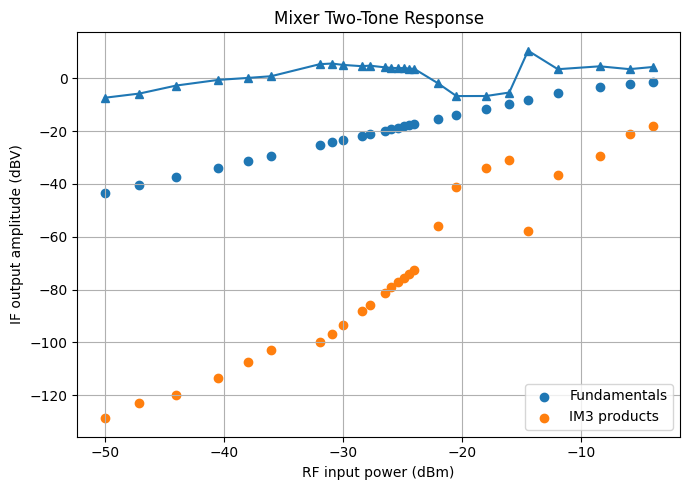

In [11]:
df_iip3 = df.copy()

df_iip3["iip3_point"]=df_iip3["Pin_dBm"]+(df_iip3["Fund_avg_dBV"]-df_iip3["IM3_avg_dBV"])/2

valid_df = df_iip3[
    (df_iip3["Arf_side_peak_V"] >= 4.5e-3)
    & (df_iip3["Arf_side_peak_V"] <= 10e-3)
].copy()

iip3_point_mean = valid_df["iip3_point"].mean()
iip3_point_std = valid_df["iip3_point"].std(ddof=1)
print(f"Mean point-wise IIP3 = {iip3_point_mean:.2f} dBm")
print(f"Standard deviation = {iip3_point_std:.2f} dB")
print(f"Number of points = {len(valid_df)}")

plt.figure(figsize=(7,5))

plt.scatter(df_iip3["Pin_dBm"], df_iip3["Fund_avg_dBV"], label = "Fundamentals")
plt.scatter(df_iip3["Pin_dBm"], df_iip3["IM3_avg_dBV"], label = "IM3 products")
plt.plot(df_iip3["Pin_dBm"], df_iip3["iip3_point"], marker="^")
plt.xlabel("RF input power (dBm)")
plt.ylabel("IF output amplitude (dBV)")
plt.title("Mixer Two-Tone Response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("iip3_scatter.png")
plt.show()

In [7]:
def fit_iip3(df_fit):
    x = df_fit["Pin_dBm"].to_numpy()
    y_fund = df_fit["Fund_avg_dBV"].to_numpy()
    y_im3 = df_fit["IM3_avg_dBV"].to_numpy()

    m_fund, b_fund = np.polyfit(x, y_fund, 1)
    m_im3, b_im3 = np.polyfit(x, y_im3, 1)

    iip3_dBm = (b_fund - b_im3) / (m_im3 - m_fund) #intersection of the 2 lines
    oip3_dBV = m_fund * iip3_dBm + b_fund #y coordinate or intersection

    return m_fund, b_fund, m_im3, b_im3, iip3_dBm, oip3_dBV


Fundamental slope: 0.99 dB/dB
IM3 slope: 3.55 dB/dB
IIP3: -2.52 dBm


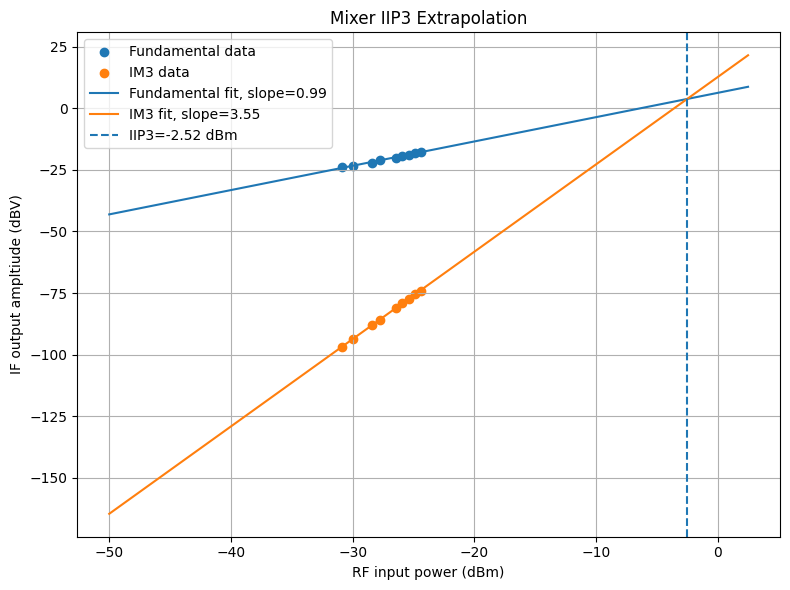

In [12]:
fit_df = df[
    (df["Arf_side_peak_V"].between(4.5e-3, 9.5e-3))
].copy()

m1, b1, m3, b3, iip3_dBm, oip3_dBV = fit_iip3(fit_df)

print(f"Fundamental slope: {m1:.2f} dB/dB")
print(f"IM3 slope: {m3:.2f} dB/dB")
print(f"IIP3: {iip3_dBm:.2f} dBm")

#plot
x_line = np.linspace(df["Pin_dBm"].min(), iip3_dBm+5, 300)

fund_line = m1*x_line + b1
im3_line = m3*x_line + b3

plt.figure(figsize=(8,6))

plt.scatter(fit_df["Pin_dBm"], fit_df["Fund_avg_dBV"], label="Fundamental data")
plt.scatter(fit_df["Pin_dBm"], fit_df["IM3_avg_dBV"], label="IM3 data")

plt.plot(x_line, fund_line, label=f"Fundamental fit, slope={m1:.2f}")
plt.plot(x_line, im3_line, label=f"IM3 fit, slope={m3:.2f}")

plt.axvline(iip3_dBm, linestyle="--", label=f"IIP3={iip3_dBm:.2f} dBm")
plt.xlabel("RF input power (dBm)")
plt.ylabel("IF output ampltiude (dBV)")
plt.title("Mixer IIP3 Extrapolation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("iip3_fit.png")
plt.show()